# Clinic 2: Introduction to Scikit-learn

Basic Workflow:
1. Load/prepare data
1. Split into train/test sets
1. Preprocess data (scaling, encoding)
1. Choose and train model
1. Make predictions
1. Evaluate performance

## 1. Classification

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

### 1. Load and explore MINST dataset

In [6]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print(f"Dataset shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature range: [{X.min():.1f}, {X.max():.1f}]")
print(f"Classes: {np.unique(y)}")

KeyboardInterrupt: 

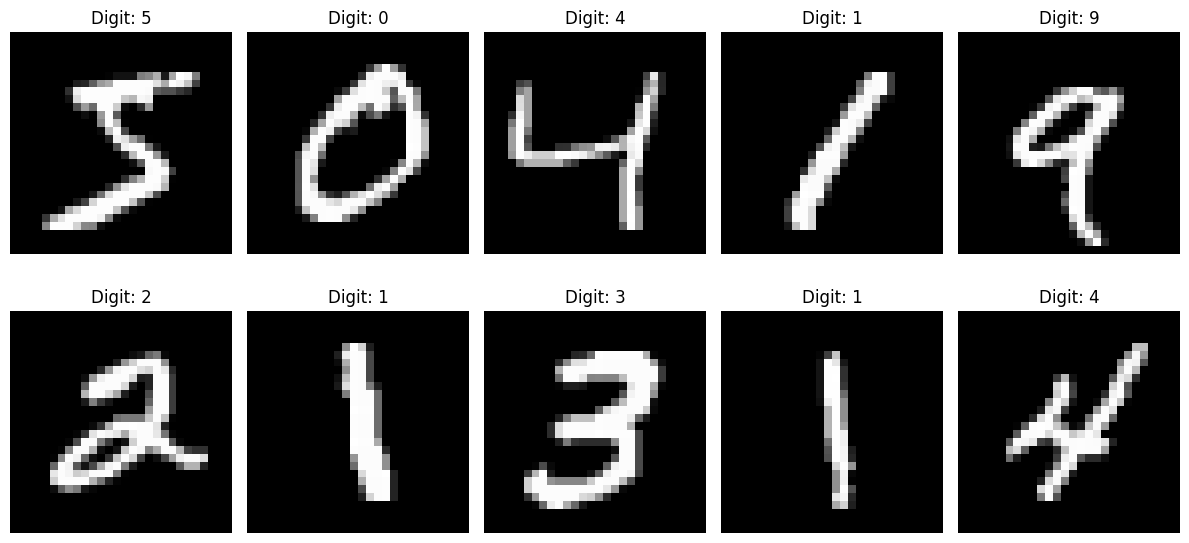

In [ ]:
# Visualize some digits
def plot_digits(X, y, n_samples=10):
    """Plot sample digits from MNIST"""
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(n_samples):
        # Reshape to 28x28 image
        image = X[i].reshape(28, 28)
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f'Digit: {y[i]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot first 10 digits
plot_digits(X, y)

Total samples: 70000
Class distribution: {0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}


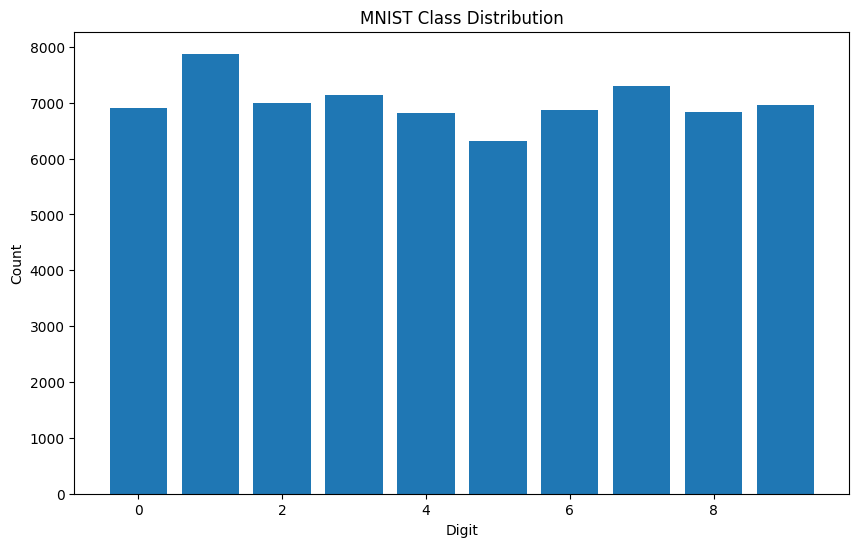

In [ ]:
# Dataset statistics
print(f"Total samples: {len(X)}")

# Class distribution
unique, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique, counts))
print(f"Class distribution: {class_distribution}")

# Visualize class distribution
plt.figure(figsize=(10, 6))
plt.bar(unique, counts)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Class Distribution')
plt.show()

### 2. Data Preprocessing

In [ ]:
# Use a subset for faster training (you can use full dataset in practice)
n_samples = 5000
X_subset = X[:n_samples]
y_subset = y[:n_samples]

print(f"Using subset of {n_samples} samples for faster training")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Using subset of 5000 samples for faster training
Train set: (4000, 784)
Test set: (1000, 784)


The model will be more biased towards features with larger values (such as height in cm and income in $10,000).

Feature scaling is used to normalize the range of independent features in a dataset.

$$
z = \frac{x - \mu}{\sigma}
$$

The result is that each feature has mean = 0 and standard deviation = 1.

In [ ]:
# Feature scaling
scaler = StandardScaler() # there are other options such as Min-Max scaling (MinMaxScaler())
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### <span style="color:orange">Are there other scaling methods?</span> 

Min-Max Scaling     

$$
z = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    

### 3. Classification Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


# Dictionary to store models and their predictions
models = {}
predictions = {}

In [ ]:
# 1. Logistic Regression
models['Logistic Regression'] = LogisticRegression(random_state=42, max_iter=1000)
models['Logistic Regression'].fit(X_train_scaled, y_train)
predictions['Logistic Regression'] = models['Logistic Regression'].predict(X_test_scaled)

In [ ]:
# 2. Decision Tree
models['Decision Tree'] = DecisionTreeClassifier(random_state=42)
models['Decision Tree'].fit(X_train_scaled, y_train)
predictions['Decision Tree'] = models['Decision Tree'].predict(X_test_scaled)

In [ ]:
# 3. Support Vector Machine
models['SVM'] = SVC(kernel='rbf', random_state=42)
models['SVM'].fit(X_train_scaled, y_train)
predictions['SVM'] = models['SVM'].predict(X_test_scaled)

In [ ]:
# 4. Naive Bayes
models['Naive Bayes'] = GaussianNB()
models['Naive Bayes'].fit(X_train_scaled, y_train)
predictions['Naive Bayes'] = models['Naive Bayes'].predict(X_test_scaled)

In [ ]:
# 5. Random Forest
models['Random Forest'] = RandomForestClassifier(n_estimators=100, random_state=42)
models['Random Forest'].fit(X_train_scaled, y_train)
predictions['Random Forest'] = models['Random Forest'].predict(X_test_scaled)

There are other SOTA methods such as XGBoost and CatBoost

In [ ]:
# 6. XGBoost
import xgboost as xgb

models['XGBoost'] = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)
models['XGBoost'].fit(X_train_scaled, y_train)
predictions['XGBoost'] = models['XGBoost'].predict(X_test_scaled)

In [ ]:
import catboost as cb

models['CatBoost'] = cb.CatBoostClassifier(random_state=42, verbose=False, iterations=100)
models['CatBoost'].fit(X_train_scaled, y_train)
predictions['CatBoost'] = models['CatBoost'].predict(X_test_scaled)

### 4. Evaluation

#### 4.1 Confusion Matrix

Confusion Matrix (Random Forest):
[[ 96   0   0   0   0   0   0   0   0   0]
 [  0 111   1   0   0   1   0   0   0   0]
 [  1   1  92   0   0   0   0   2   1   0]
 [  0   0   2  88   0   4   1   0   1   3]
 [  0   0   2   0 102   0   0   0   0   3]
 [  2   0   0   1   0  80   0   1   0   3]
 [  0   0   0   0   0   0 100   0   0   0]
 [  0   1   1   0   3   0   0 102   0   3]
 [  0   0   2   0   1   2   0   0  83   4]
 [  2   0   0   1   1   0   0   2   0  93]]


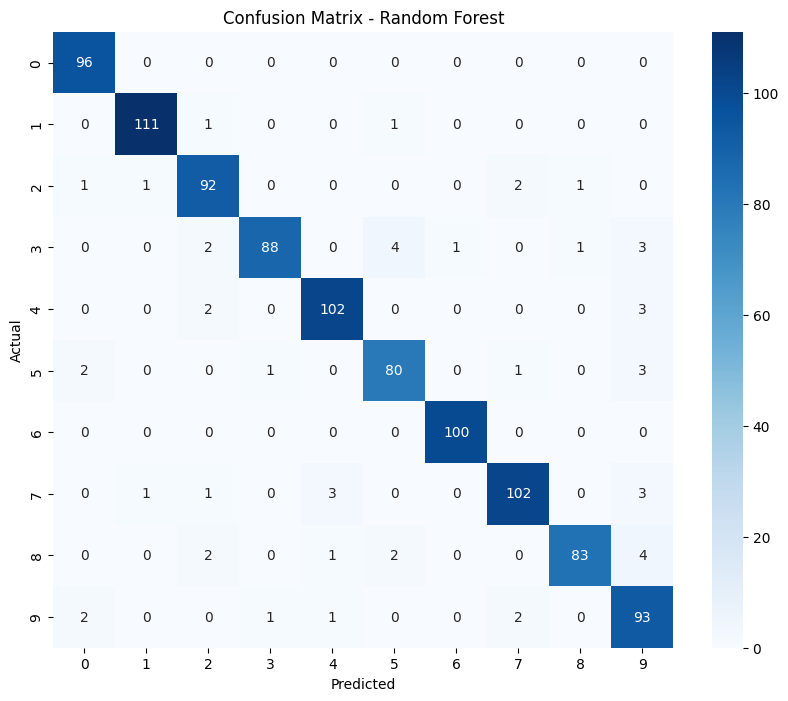

In [ ]:
# Let's use Random Forest for explanation
rf_predictions = predictions['Random Forest']

# Create confusion matrix
cm = confusion_matrix(y_test, rf_predictions)
print("Confusion Matrix (Random Forest):")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 4.2 TP, TN, FP, FN

use digit 0 as an example. Positive is 0, and negative is non-zero.

* True Positive (TP): Correctly predicted as positive (digit 0)
* True Negative (TN): Correctly predicted as negative (not digit 0)
* False Positive (FP): Incorrectly predicted as positive (predicted 0, but not 0)
* False Negative (FN): Incorrectly predicted as negative (predicted not 0, but is 0)

**Detect a very rare disease that only affects 1% of the population**
* lazy model, predicts every single persone as "not having the disease"
* What would its accuracy be?

Binary Classification: Digit 0 vs Not-0
True Negatives (TN): 899
False Positives (FP): 5
False Negatives (FN): 0
True Positives (TP): 96


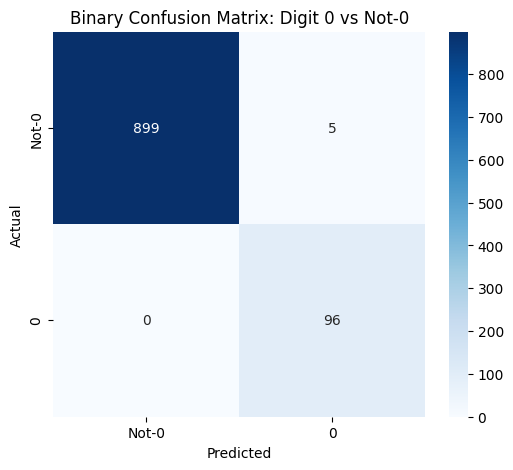

In [ ]:
# For binary classification explanation, let's create a binary problem
# Classify digit 0 vs not-0
y_binary = (y_test == 0).astype(int)  # 1 if digit is 0, 0 otherwise
pred_binary = (rf_predictions == 0).astype(int)

# Calculate confusion matrix for binary case
cm_binary = confusion_matrix(y_binary, pred_binary)
tn, fp, fn, tp = cm_binary.ravel()

print("Binary Classification: Digit 0 vs Not-0")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Visualize binary confusion matrix
plt.figure(figsize=(6, 5))
labels = ['TN', 'FP', 'FN', 'TP']
values = [tn, fp, fn, tp]
cm_display = np.array([[tn, fp], [fn, tp]])

sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not-0', '0'], yticklabels=['Not-0', '0'])
plt.title('Binary Confusion Matrix: Digit 0 vs Not-0')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 4.3 Accuracy

In [ ]:
# Accuracy

# Manual calculation
total_samples = tn + fp + fn + tp
correct_predictions = tp + tn
accuracy_manual = correct_predictions / total_samples

print(f"Accuracy = (TP + TN) / (TP + TN + FP + FN)")
print(f"Accuracy = ({tp} + {tn}) / ({tp} + {tn} + {fp} + {fn})")
print(f"Accuracy = {correct_predictions} / {total_samples}")
print(f"Accuracy = {accuracy_manual:.4f}")

# Using sklearn
accuracy_sklearn = accuracy_score(y_binary, pred_binary)
print(f"Sklearn accuracy: {accuracy_sklearn:.4f}")

# Overall accuracy (for all 10 digits)
accuracy_multiclass = accuracy_score(y_test, rf_predictions)
print(f"Overall accuracy: {accuracy_multiclass:.4f}")

Accuracy = (TP + TN) / (TP + TN + FP + FN)
Accuracy = (96 + 899) / (96 + 899 + 5 + 0)
Accuracy = 995 / 1000
Accuracy = 0.9950
Sklearn accuracy: 0.9950
Overall accuracy: 0.9470


#### 4.4 Precision, Recall, and F1-Score

In [ ]:
# Precision, Recall, and F1-Score
print("PRECISION, RECALL, AND F1-SCORE")
print("=" * 40)

# Manual calculations
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Precision = TP / (TP + FP)")
print(f"Precision = {tp} / ({tp} + {fp}) = {precision:.4f}")
print("→ Of all positive predictions, how many were correct?")

print(f"\nRecall = TP / (TP + FN)")
print(f"Recall = {tp} / ({tp} + {fn}) = {recall:.4f}")
print("→ Of all actual positives, how many were correctly identified?")

print(f"\nF1-Score = 2 × (Precision × Recall) / (Precision + Recall)")
print(f"F1-Score = 2 × ({precision:.4f} × {recall:.4f}) / ({precision:.4f} + {recall:.4f})")
print(f"F1-Score = {f1_score:.4f}")
print("→ Harmonic mean of precision and recall")

# Using sklearn
from sklearn.metrics import precision_score, recall_score, f1_score
precision_sklearn = precision_score(y_binary, pred_binary)
recall_sklearn = recall_score(y_binary, pred_binary)
f1_sklearn = f1_score(y_binary, pred_binary)

print(f"\nSklearn verification:")
print(f"Precision: {precision_sklearn:.4f}")
print(f"Recall: {recall_sklearn:.4f}")
print(f"F1-Score: {f1_sklearn:.4f}")

PRECISION, RECALL, AND F1-SCORE
Precision = TP / (TP + FP)
Precision = 96 / (96 + 5) = 0.9505
→ Of all positive predictions, how many were correct?

Recall = TP / (TP + FN)
Recall = 96 / (96 + 0) = 1.0000
→ Of all actual positives, how many were correctly identified?

F1-Score = 2 × (Precision × Recall) / (Precision + Recall)
F1-Score = 2 × (0.9505 × 1.0000) / (0.9505 + 1.0000)
F1-Score = 0.9746
→ Harmonic mean of precision and recall

Sklearn verification:
Precision: 0.9505
Recall: 1.0000
F1-Score: 0.9746


##### <span style="color:orange"> FP or FN, which is more unacceptable? </span>

**Wisconsin breast cancer dataset**. The goal is to predict whether a tumor is malignant (cancerous) or benign (not cancerous). Let's define our 'positive' class as 'malignant'.

#### 4.5 Evaluation across all models

In [ ]:
# Evaluation for all models
results = []

for model_name, model_preds in predictions.items():
    accuracy = accuracy_score(y_test, model_preds)
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Accuracy %': f"{accuracy*100:.2f}%"
    })

# Convert to DataFrame for better display
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df)

                 Model  Accuracy Accuracy %
2                  SVM     0.965     96.50%
5              XGBoost     0.951     95.10%
4        Random Forest     0.947     94.70%
6             CatBoost     0.934     93.40%
0  Logistic Regression     0.924     92.40%
1        Decision Tree     0.783     78.30%
3          Naive Bayes     0.581     58.10%


## 2. Try some regression tasks

Linear Regression / SVR / Decision Tree / Random Forest / Etc.

MSE / RMSE / R^2 instead of accuracy / F1 score

### <span style="color:orange"> Let's do it together </span>

Goal: Predict a person's body fat percentage based on various body measurements.

Dataset: OpenML: [OpenML Dataset 560](https://api.openml.org/d/560)

### 1. Load and Understand the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
bodyfat = fetch_openml('BodyFat', version=1, as_frame=True, parser='liac-arff')
df = bodyfat.frame

X = df.drop('class', axis=1)
y = df['class']
print(X.head())
print(y.head())

   Density   Age  Weight  Height  Neck  Chest  Abdomen    Hip  Thigh  Knee  \
0   1.0708  23.0  154.25   67.75  36.2   93.1     85.2   94.5   59.0  37.3   
1   1.0853  22.0  173.25   72.25  38.5   93.6     83.0   98.7   58.7  37.3   
2   1.0414  22.0  154.00   66.25  34.0   95.8     87.9   99.2   59.6  38.9   
3   1.0751  26.0  184.75   72.25  37.4  101.8     86.4  101.2   60.1  37.3   
4   1.0340  24.0  184.25   71.25  34.4   97.3    100.0  101.9   63.2  42.2   

   Ankle  Biceps  Forearm  Wrist  
0   21.9    32.0     27.4   17.1  
1   23.4    30.5     28.9   18.2  
2   24.0    28.8     25.2   16.6  
3   22.8    32.4     29.4   18.2  
4   24.0    32.2     27.7   17.7  
0    12.3
1     6.1
2    25.3
3    10.4
4    28.7
Name: class, dtype: float64


In [7]:
print(X.describe())

          Density         Age      Weight      Height        Neck       Chest  \
count  252.000000  252.000000  252.000000  252.000000  252.000000  252.000000   
mean     1.055574   44.884921  178.924405   70.148810   37.992063  100.824206   
std      0.019031   12.602040   29.389160    3.662856    2.430913    8.430476   
min      0.995000   22.000000  118.500000   29.500000   31.100000   79.300000   
25%      1.041400   35.750000  159.000000   68.250000   36.400000   94.350000   
50%      1.054900   43.000000  176.500000   70.000000   38.000000   99.650000   
75%      1.070400   54.000000  197.000000   72.250000   39.425000  105.375000   
max      1.108900   81.000000  363.150000   77.750000   51.200000  136.200000   

          Abdomen         Hip       Thigh        Knee       Ankle      Biceps  \
count  252.000000  252.000000  252.000000  252.000000  252.000000  252.000000   
mean    92.555952   99.904762   59.405952   38.590476   23.102381   32.273413   
std     10.783077    7.1640

### 2. Data Preprocessing

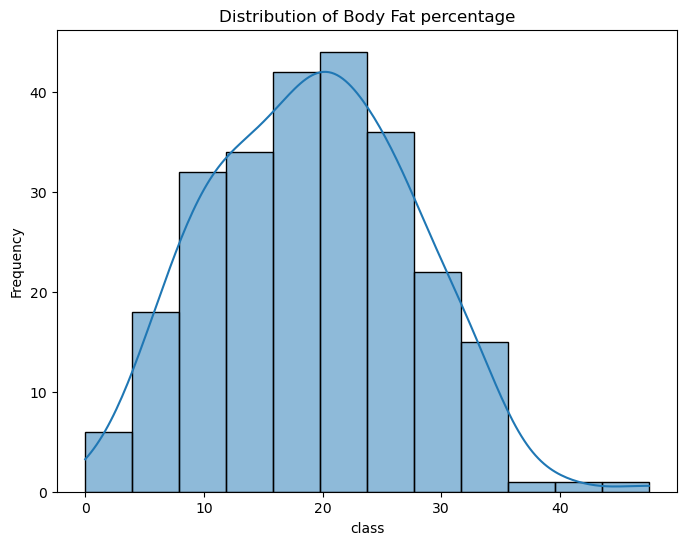

In [10]:
plt.figure(figsize=(8, 6))
sns.histplot(y, kde=True)
plt.title("Distribution of Body Fat percentage")
plt.xlabel;('Body Fat Percentage')
plt.ylabel('Frequency')
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: { X_train.shape }")
print(f"Test set: { X_test.shape }")

Train set: (201, 14)
Test set: (51, 14)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Training the model

In [14]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

### 4. Evaluation and prediction

In [15]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")